T-Rex running in High Resolution mode, with cententral wavelength = 2.50 Å, RRM = 12.
Pulse shaping chopper frequency = 126 Hz, Monochromatic chopper frequency = 168 Hz


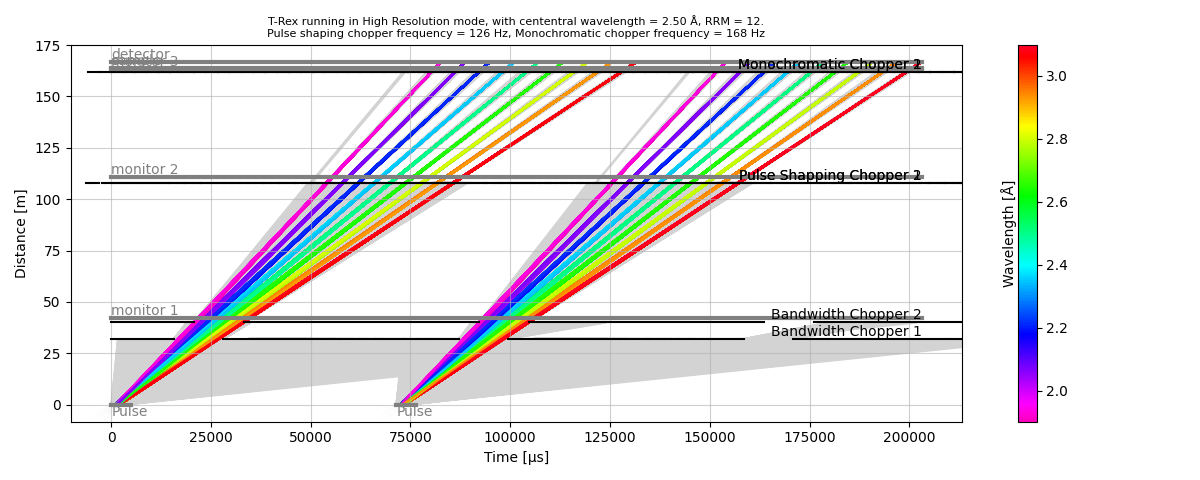

In [1]:
%matplotlib widget
import tof
import scipp as sc
from trex.instrument import Instrument
import matplotlib.pyplot as plt

T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(2.5, unit="Å")
rrm: int = 12 # repetition rate multiplication factor
mode = "High Resolution"  # Chopper mode


trex=Instrument(wavelength=central_wavelength,rrm=rrm,mode=mode,t_offset=T_OFFSET)
trex.source = tof.Source(facility="ess", neutrons=5_000_000, pulses=2)
print(trex)
res = trex.model.run()
p = res.plot(visible_rays=1_000_000, blocked_rays=50_000)

p.ax.set_title(trex, fontsize=8)
p.ax.grid(alpha=0.6)
p.fig.tight_layout()

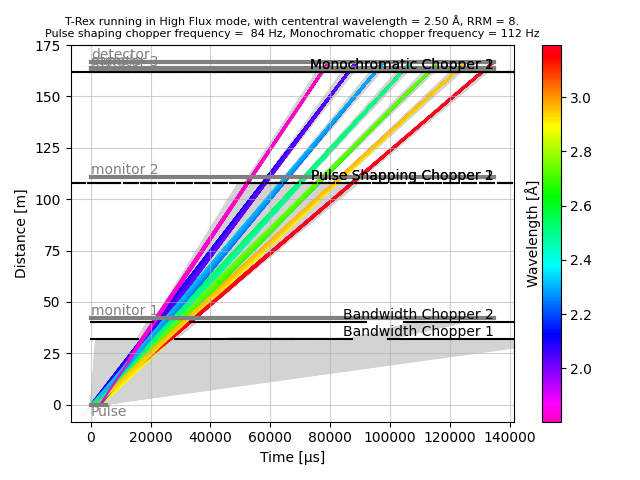

In [2]:
T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(2.5, unit="Å")
rrm: int = 8 # repetition rate multiplication factor
mode = "High Flux"  # Chopper mode


trex=Instrument(wavelength=central_wavelength,rrm=rrm,mode=mode,t_offset=T_OFFSET)
res = trex.model.run()
p = res.plot(visible_rays=500_000, blocked_rays=50_000)

p.ax.set_title(trex, fontsize=8)
p.ax.grid(alpha=0.6)
p.fig.tight_layout()


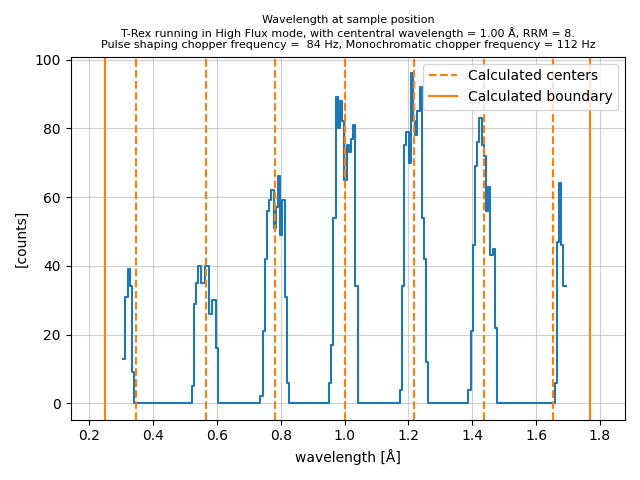

In [6]:
T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(1, unit="Å")
rrm: int = 8 # repetition rate multiplication factor
mode = "High Flux"  # Chopper mode

trex=Instrument(wavelength=central_wavelength,rrm=rrm,mode=mode,t_offset=T_OFFSET)
res = trex.model.run()

# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]

fig, ax = plt.subplots()
events_at_sample.hist(wavelength=200).plot(ax=ax)
ax.set_title('Wavelength at sample position\n'+str(trex), fontsize=8)

delta_lambda = trex.calculate_delta_lambda()
# plot expected Ei wavelength
bw = trex.calculate_bandwidth()
lambda_i = trex.calculate_incoming_wavelength(bw)

for lam in lambda_i:
    vline_i = ax.axvline(x = lam.values, c = 'C1', linestyle='--')
for w in bw:
    vline_bw = ax.axvline(x = w.values, c = 'C1', linestyle='-')

ax.legend([vline_i,vline_bw],['Calculated centers','Calculated boundary'])
ax.grid(alpha=0.6)
ax.set_xlim([(bw[0]-delta_lambda/2).value,(bw[1]+delta_lambda/2).value])
fig.tight_layout()


In [7]:
trex.calculate_incoming_energy()

[<scipp.Variable> ()    float64            [meV]  683.738,
 <scipp.Variable> ()    float64            [meV]  257.233,
 <scipp.Variable> ()    float64            [meV]  133.783,
 <scipp.Variable> ()    float64            [meV]  81.8042,
 <scipp.Variable> ()    float64            [meV]  55.1386,
 <scipp.Variable> ()    float64            [meV]  39.6665,
 <scipp.Variable> ()    float64            [meV]  29.8985]